# 1c

In [30]:
from __future__ import print_function
import numpy as np

def kmeans(X, k, init=None):
    """ KMEANS implements the k-means algorithm.

    [CLUSTERS, CENTROIDS] = KMEANS(X, K) partitions the data points
    in the N-by-P data matrix X into K distinct clusters, using Euclidean
    distance. This is a simple implementation of the k-means algorithm with
    random initialization.

    Optionally, it takes the argument INIT, a K-by-P matrix with a fixed
    initial position for the cluster centroids.  

    MYKMEANS returns an N-by-1 vector CLUSTERS containing the cluster
    indices of each data point, as well as CENTROIDS, a K-by-P matrix with 
    the final cluster centroids' locations.
    """


    n, p = X.shape

    if init is None:
      #choose initial centroids by picking k points at random from X
      init = X[np.random.randint(n, size=k), :]
    
    #centroids is a k-by-p random matrix
    #its i^th row contains the coordinates of the cluster with index i
    centroids = init

    #initialize cluster assignment array
    clusters = np.zeros(n)

    MAXITER = 1000

    for iter in range(MAXITER):
        
        #create a new clusters vector to fill in with updated assignments
        new_clusters = np.zeros(n)
        

        #for each data point x_i
        for i in range(n):
            
            x_i = X[i,:]
            
            #find closest cluster
            closest = findClosestCluster(x_i,centroids)###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE

            #reassign x_i to the index of the closest centroid found
            new_clusters[i] = closest

        
        
        if hasConverged(clusters,new_clusters):###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE
            #exit loop
            break 
        
        #otherwise, update assignment
        clusters = new_clusters
        #and recompute centroids
        centroids = recomputeCentroids(X,clusters,k)###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE

    if iter == (MAXITER-1):
        print('Maximum number of iterations reached!')
    
    return clusters, centroids
    

def findClosestCluster(x_i,centroids):
    # Compute Euclidean distance from x_i to each cluster centroid and return 
    # the index of the closest one (an integer).
    # NOTE: use of numpy/scipy.linalg.norm function is NOT allowed here.

    ### Replace the following line with your own code
    closest = min(range(len(centroids)), 
                  key=lambda i:np.sum((x_i - centroids[i])**2)
    )
    return closest

def hasConverged(old_assignment, new_assignment):
    # Check if algorithm has converged, i.e., cluster assignments haven't
    # changed since last iteration. Return a boolean.

    ### Replace the following line with your own code
    map = {}
    converged = True

    for i in range(len(old_assignment)):
        if old_assignment[i] != new_assignment[i]:
            converged = False
            break

    return converged

def recomputeCentroids(X,clusters,k):
    # Recompute centroids based on current cluster assignment.
    # Return a k-by-p array where each row is a centroid. 
    row, col = X.shape
    ### Replace the following line with your own code
    centroids = np.zeros(
        (k,col)
        )
    for i in range(k):
        points = X[clusters==i] 
        if len(points) > 0: 
            centroids[i] = points.mean(axis=0)
    return centroids
    

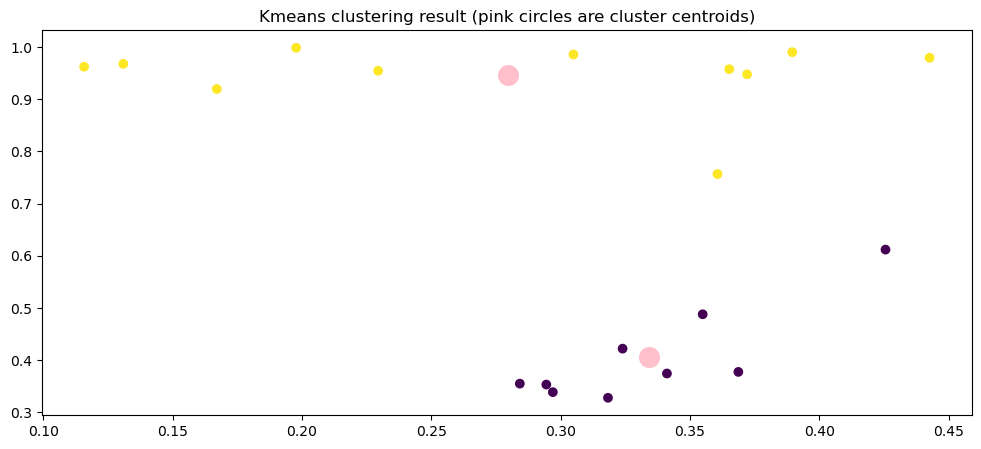

In [31]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

x = loadmat("tinypics.mat")["data"]
clusters, centroids = kmeans(x, k=2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plt.scatter(x[:, 0], x[:, 1], c=clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], c="pink", s=200)
plt.title("Kmeans clustering result (pink circles are cluster centroids)")
plt.show()

# 2a

The separation here is pretty clear. Just look at the top half vs the bottom half of the plot. In 5 images, the "Y" in yale is boldened with a photo of a bulldog. In the other 5, the "Y" matches the rest of the letters in Yale.

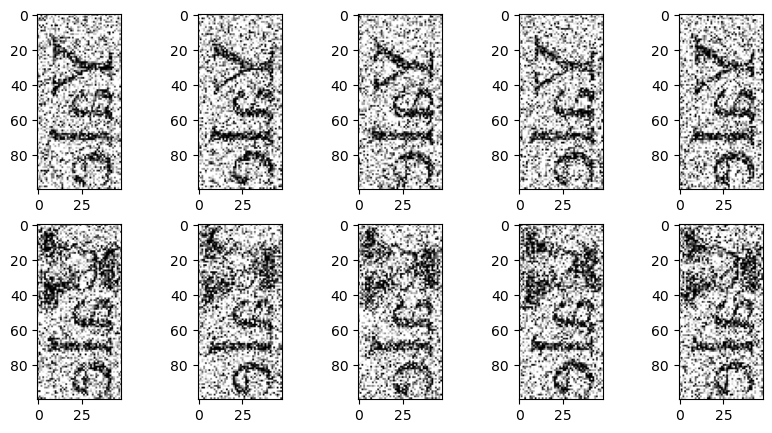

In [3]:
data = loadmat("logos.mat")["data"]
images = []
num_images = 10
fig, axes = plt.subplots(2, int(num_images/2), figsize=(10, 5))
for i in range(0, num_images, 1):
    row=i//5
    col=i%5
    axes[row, col].imshow(data[:,:,i].T, cmap='gray')

# 2b

it would not be possible to create a similar scatterplot because each of the ten images lives in 4800 dimmensional space because we flattened them down. Each row in the matrix has 4800 dimmensions. We could use PCA to reduce the dimmensionality if we desired.

In [57]:
x= np.zeros((10, 4800))
for i in range(10):
    x[i,:] = data[:,:,i].T.flatten()
print(x.shape)
print(x[0, :])
print(len(x[0,:]))


(10, 4800)
[1.         1.         0.         ... 1.         0.69672166 1.        ]
4800


# 2c

The 10 kmeans runs do not always produce the same results! We see many differences, it is not always the case that the clusters are perfectly allocated as five and five. Rather, we see substantial variability accross distinct runs. If we look at those runs where the five and five allocation was properly achieved, we see promising results that are exactly what we would expect (matching up well with the initial plots except with significantly less noise). You can clearly see the "bulldog" face within the Y of yale on one plot and just a simple 'yale' on the other. Plots where kmeans incorrectly clustered the dataset are not clear (say, 7 on one side 3 on the other), as it becomes much more difficult to distinguish the two plots. This makes sense, as in these cases, kmeans is not doing a great job of clustering together the related plots, and therefore, we have features of incorrect classes being treated as signal for the wrong class! Kmeans is very sensitive to its initial randomization which leads to this variability b/c each cluster may not converge to the global minima, instead landing in local minima.


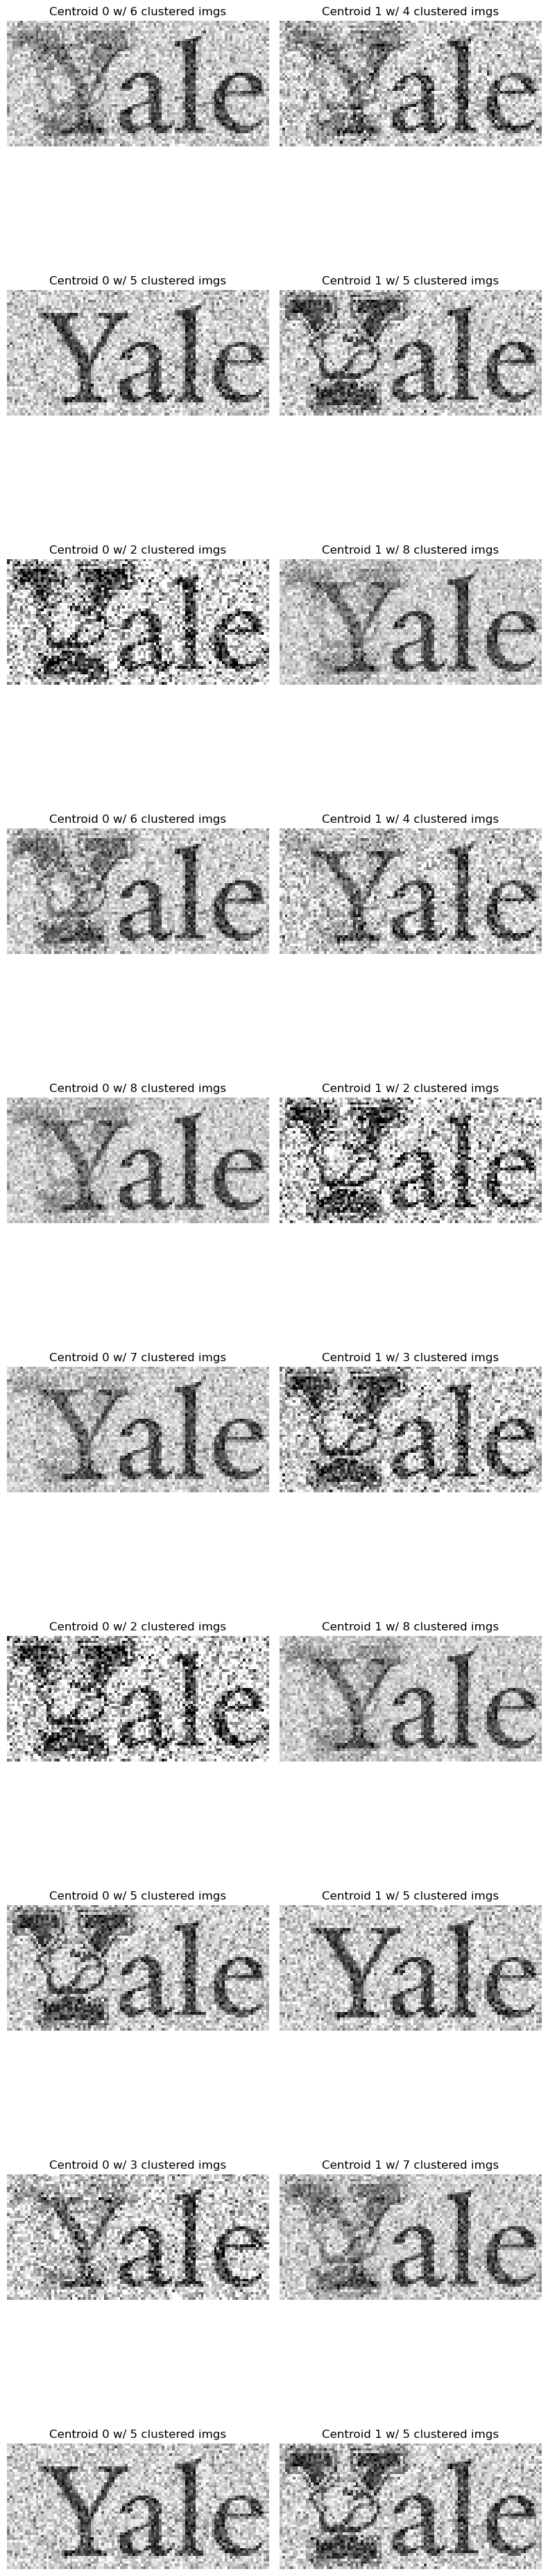

In [62]:
num_runs = 10
fig, axes = plt.subplots(num_runs, 2, figsize=(8, 4*num_runs))

for run in range(num_runs):
    clusters, centroids = kmeans(x, k=2)
     
    cluster_0 = np.where(clusters == 0)[0] # grab all of em where cluster assignment is 0
    cluster_1 = np.where(clusters == 1)[0] # same, except when its 1

    centroid_0 = centroids[0].reshape(100, 48).T
    centroid_1 = centroids[1].reshape(100, 48).T
    
    axes[run, 0].imshow(centroid_0, cmap="gray")
    axes[run, 0].set_title(f"Centroid 0 w/ {len(cluster_0)} clustered imgs")
    axes[run, 0].axis("off")
    
    axes[run, 1].imshow(centroid_1, cmap="gray")
    axes[run, 1].set_title(f"Centroid 1 w/ {len(cluster_1)} clustered imgs")
    axes[run, 1].axis("off")

plt.tight_layout()
plt.show()


# 3a

In [41]:
from scipy.sparse.linalg import eigs

def pca(X, m):
    n, _ = X.shape
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean
    
    covariance_matrix = (1 / (n - 1)) * (X_centered.T @ X_centered)
    evals, evec = eigs(covariance_matrix, k=m, which="LM")
    evals = evals.real
    evec = evec.real
    
    sorted = np.argsort(evals)[::-1]
    evals = evals[sorted]
    evec = evec[:, sorted]
    
    components = evec[:, :m]
    variances = evals[:m]
    
    return components, variances

# 3b

/var/folders/km/9hmy_qv946z1t5m7z35vf6600000gn/T/ipykernel_71838/2464867155.py:9: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  evals, evec = eigs(covariance_matrix, k=m, which="LM")


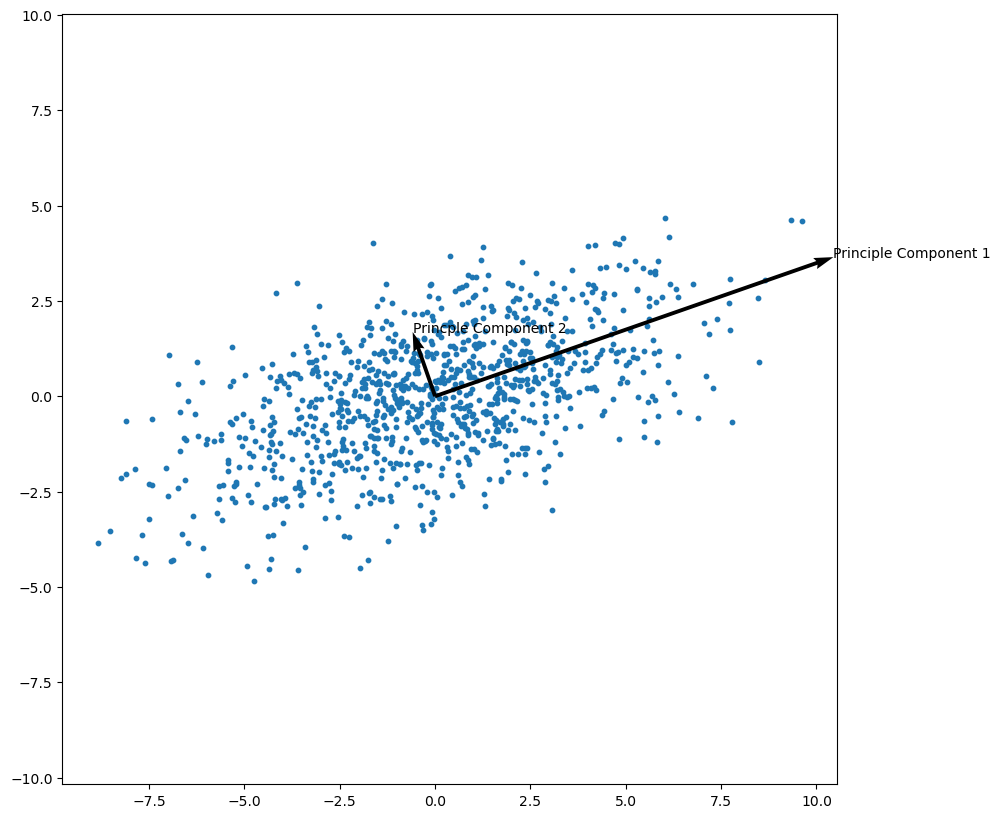

In [42]:
g = loadmat('gaussian.mat')['gaussian']

components, variances = pca(g, m=2)
pc_scaled_one = variances[0] * components[:, 0] # scale by variance
pc_scaled_two = variances[1] * components[:, 1]

plt.figure(figsize=(10, 10))
plt.scatter(g[:, 0], g[:, 1], s=10)

plt.quiver([0, 0], 
           [0, 0], 
           [pc_scaled_one[0], 
            pc_scaled_two[0]], 
           [pc_scaled_one[1], 
            pc_scaled_two[1]], 
           scale=1, 
           scale_units='xy', 
           width=0.005)

plt.text(pc_scaled_one[0], pc_scaled_one[1], "Principle Component 1")
plt.text(pc_scaled_two[0], pc_scaled_two[1], "Princple Component 2")
plt.axis("equal")

plt.show()

# 4a

It seems like the first principle component captures the vast majority of the variance in the data, which is also evident by observation of the first plot which has a very distinctive portion which matches up with the portion of the dataset that is distinct between the two different classes (the "Yale" with vs w/o a bulldog in the y). This first principle component captures the vast majority of the variance (98.04) in comparison to the others, with pc2, pc3, and pc4 being very close (55.00, 51.56, 50.87). The variance decay does not occur rapidly after the first principle component, as successive components are relatively similar in their coverage of the variance. Therefore, I would conclude that we only really need 2 components to sufficiently represent this dataset and capture the two distinct classes of images! Because pc3 and pc4 do not add much meaningful information beyond pc2, I would leverage pc1 and pc2 to represent the dataset. This result is what I expected, because its a binary classification problem with clear visual separation.

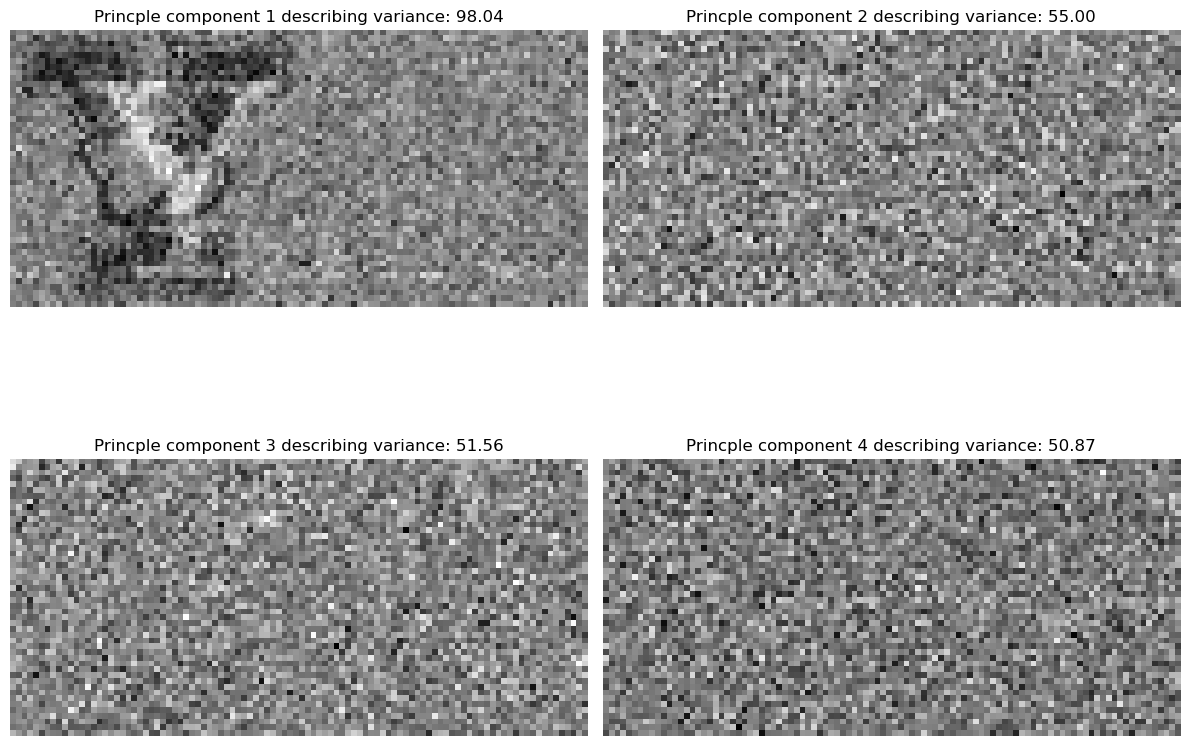

In [63]:
num_components = 4
components, variances = pca(X=x, m=num_components)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
for idx in range(num_components):
    row = idx // 2
    col = idx % 2
    
    pc_image = components[:, idx].reshape(100, 48).T
    
    im = ax[row, col].imshow(pc_image, cmap="gray")
    ax[row, col].set_title(f"Princple component {idx+1} describing variance: {variances[idx]:.2f}", fontsize=12)
    ax[row, col].axis("off")

plt.tight_layout()
plt.show()

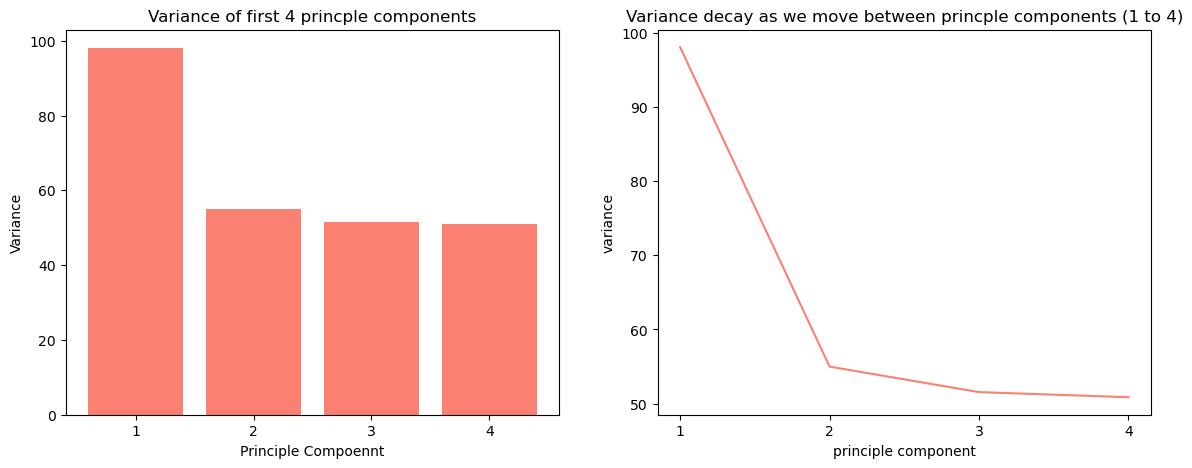

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ticks=[1,2,3,4]
ax1.bar(ticks, variances, color="salmon")
ax1.set_xlabel("Principle Compoennt")
ax1.set_ylabel("Variance")
ax1.set_title("Variance of first 4 princple components")
ax1.set_xticks(ticks)

ax2.plot(ticks, variances, color="SALMON")
ax2.set_xlabel("principle component")
ax2.set_ylabel("variance")
ax2.set_title("Variance decay as we move between princple components (1 to 4)")
ax2.set_xticks(ticks)
plt.show()

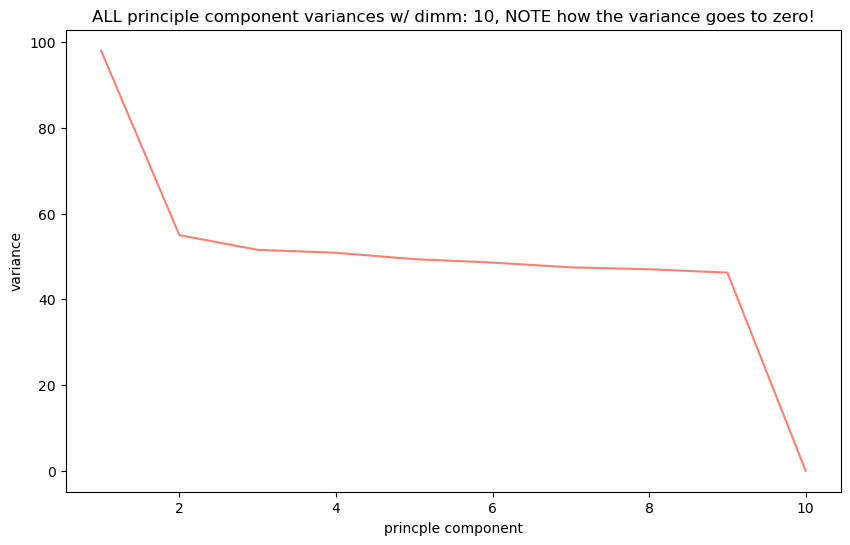

In [65]:
dimmensionality = min(x.shape)
all_components, all_variances = pca(x, m=dimmensionality)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot([1,2,3,4,5,6,7,8,9,10], all_variances, color="SALMON")
ax.set_xlabel("princple component")
ax.set_ylabel("variance")
ax.set_title(f"ALL principle component variances w/ dimm: {dimmensionality}, NOTE how the variance goes to zero!")
plt.show()

# 4c

The components matrix encodes a new basis for describing the data. For example, the first principle component describes a direction of greatest variance. If we project onto this direction, we will gather the components that account for the majority of the variation over the entire data matrix. Essentially, we are projecting the original data into a lower dimmensional basis that describes the maximal amount of variation that can be captured in a limited number of dimmensions (based on the # of principle components leveraged). If we at the final plot from the previous problem, we can see this in action. After 10 dimmensions (principle components), we can fully describe the dimmensionality of the data and thus, we capture all information. As we move left, the amount of the variance that can be described falls with each successive principle component, with the greatest capture occuring in the first principle component. Note that each column of the compoent matrix is a new basis vector (principle component), and each of these vectors is orthoganol to one another! So thus, when we compute X_centered @ first_principle_component, we are projecting the data into a new basis! The result is the coordiantes of each data point in this new basis.

In [47]:
X_mean = x.mean(axis=0)
X_centered = x - X_mean
first_principle_component = components[:, 0] 
X_projected = X_centered @ first_principle_component 

print(f"\n projected data shape: {X_projected.shape}")
print(f" New dimensionality: {X_projected.shape[0]}")
print(f"\n Projected coordinates (coefficients along principle component one):")
for i in range(10):
    print(f"image {i} w/ coefficient: {X_projected[i]}")


 projected data shape: (10,)
 New dimensionality: 10

 Projected coordinates (coefficients along principle component one):
image 0 w/ coefficient: -9.397275256446628
image 1 w/ coefficient: -8.937497936635276
image 2 w/ coefficient: -10.028135269441501
image 3 w/ coefficient: -9.0952570695765
image 4 w/ coefficient: -9.436166265354357
image 5 w/ coefficient: 9.620770750707385
image 6 w/ coefficient: 8.22325660713363
image 7 w/ coefficient: 9.541004644932373
image 8 w/ coefficient: 10.151094890480842
image 9 w/ coefficient: 9.35820490420002


# 4d

It looks consistent (mostly). Just two runs out of 10 exhibit imperfect (non 5-5) classification of the data. In those runs with perfect classification, you can clearly see the outline of the "bulldog y" within one plot. In those plots without perfect splits, it looks almost as if the classifier is attempting to capture the variability accross both classes, leading to a muddled visual. Note that, if we observe the 2D scatterplot in these cases, ALL points are classified in the same cluster, which leads to this murkied visual! In those two cases, it incorrectly classifies half the data (achieving a 0-10 split). In contrast, when we have that perfect 5-5 split and nice viusal separation, the 2D scatterplot shows two perfectly split clusters of closely spaced datapoints. We continue our analysis in part 3.

In [67]:
components, variances = pca(x, m=1)

/var/folders/km/9hmy_qv946z1t5m7z35vf6600000gn/T/ipykernel_71838/1787886485.py:24: RuntimeWarning: Mean of empty slice.
  centroid_img_1 = x[cluster_1_indices].mean(axis=0)
/opt/anaconda3/envs/cpsc4750/lib/python3.12/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


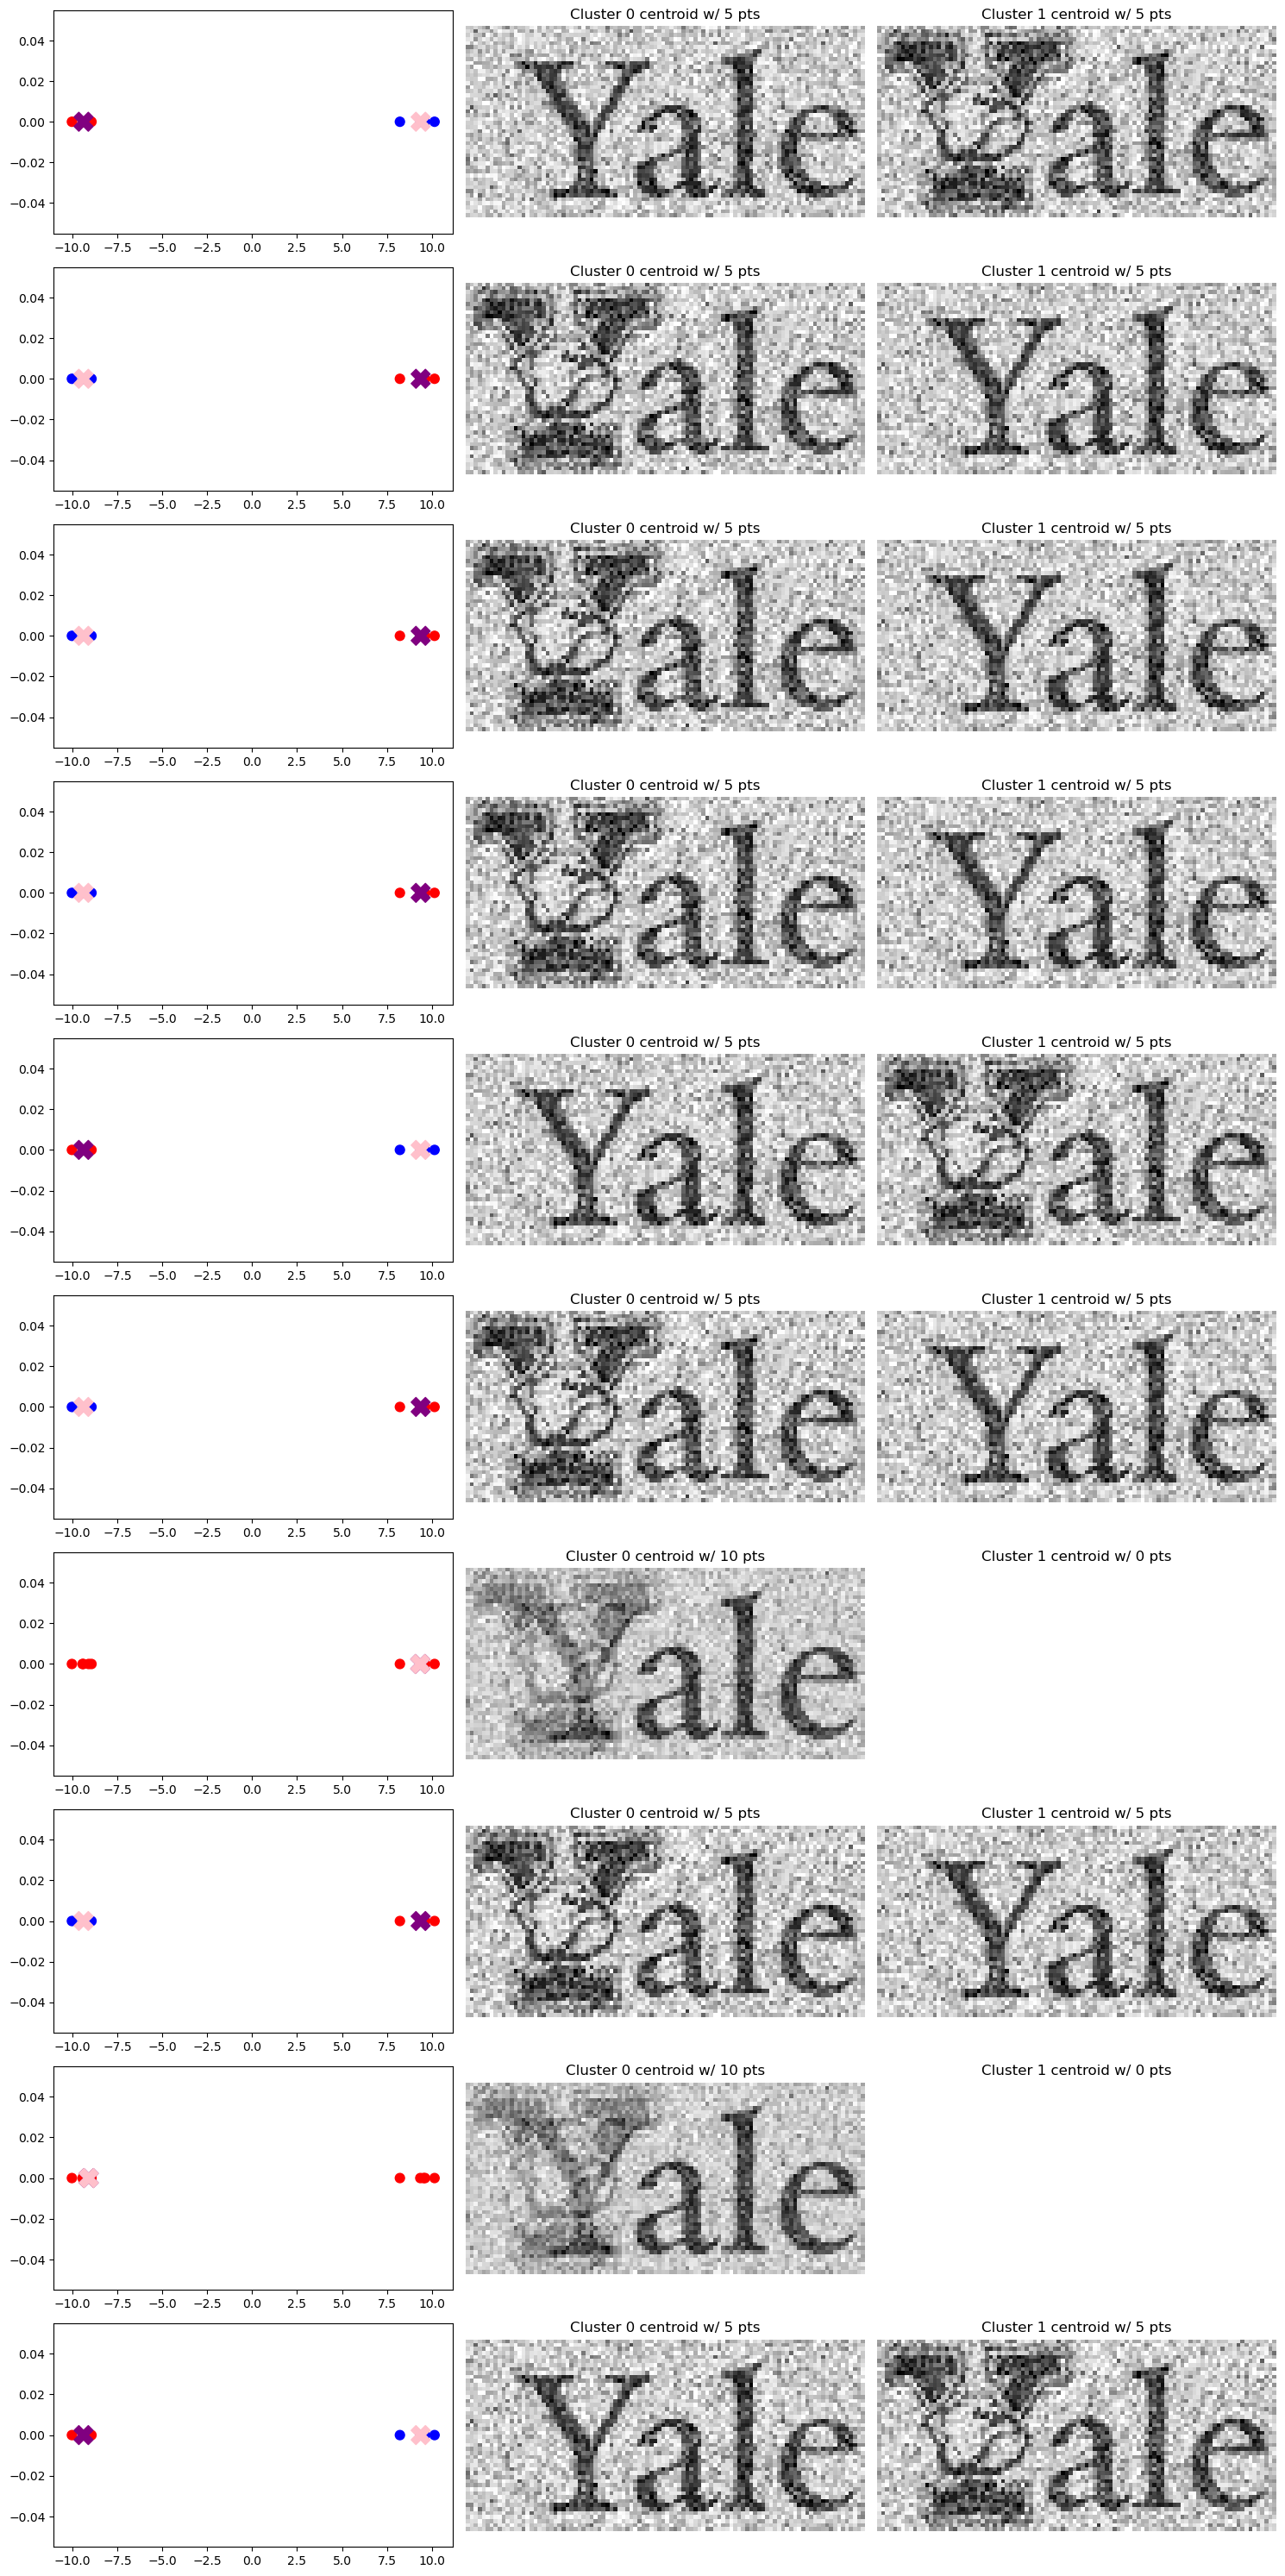

In [68]:
x_mean = x.mean(axis=0)
x_centered = x - x_mean
first_principle_component = components[:, 0]
x_proj = x_centered @ first_principle_component
data_one_dimm = x_proj.reshape(-1, 1)

num_runs = 10
fig, ax = plt.subplots(num_runs, 3, figsize=(15, 3*num_runs))

for run in range(num_runs):
    clusters, centroids = kmeans(data_one_dimm, k=2)
    
    cluster_0_indices = np.where(clusters == 0)[0]
    cluster_1_indices = np.where(clusters == 1)[0]
    colors = []
    for color in clusters:
        colors.append("red" if color == 0 else "blue")
    scatter_y_values = np.zeros_like(x_proj)

    ax[run, 0].scatter(x_proj, scatter_y_values, c=colors, s=60)
    ax[run, 0].scatter(centroids[:, 0], [0, 0], c=['purple', 'pink'], s=250, marker='X')

    centroid_img_0 = x[cluster_0_indices].mean(axis=0)
    centroid_img_1 = x[cluster_1_indices].mean(axis=0)

    centroid_0_reshaped = centroid_img_0.reshape(100, 48).T
    centroid_1_reshaped = centroid_img_1.reshape(100, 48).T
    
    ax[run, 1].imshow(centroid_0_reshaped, cmap="gray")
    ax[run, 1].set_title(f"Cluster 0 centroid w/ {len(cluster_0_indices)} pts")
    ax[run, 1].axis('off')
    ax[run, 2].imshow(centroid_1_reshaped,cmap="gray")
    ax[run, 2].set_title(f"Cluster 1 centroid w/ {len(cluster_1_indices)} pts")
    ax[run, 2].axis('off')

plt.tight_layout()
plt.show()

# 4e

Clearly, this reduced dimmensionality approach is much more consistent, which only had 4 perfect 5-5 classifications out of 10 original full dimmensionality kmeans runs. The initial kmeans result leverages the complete dimmensionality of the dataset (4800 dimensions). In contrast, using PCA, we reduced the dimmensionality down to just the first principle component and saw much better results. This follows from the infamous curse of dimmensionality, which is a result stemming from the fact that when kmeans attempts to compute euclidian distances in high dimmensional space it becomes overwhelmingly skewed by noise present in the dataset. This pixel basis contains overwhelmingly irrelevant information in the 4800 dimm space, because every pixel is treated as equal, and this creates no distinction between high and low signal features. In contrast, by projecting onto the first principle component (to get into the principle component basis which becomes our coordinate system), the single dimmension that captures the most variance becomes the new basis. This new coordinate system does a much better job capturing the meaningful distinctions between the two classes. We project into the principle component basis, which reduces the vast noisiness of high dimmensional data, allowing kmeans to focus on the highest signal features. By projecting onto the first principal component we create a new coordinate system that captures the single dimension with maximum variance which happens to align with the visual distinction between the "bulldog Y" and the plain "Y" Yale logos. This basis reduces the vast noisiness of high dimm data, allowing k-means to focus on the highest signal features. Since this is a binary classification problem and the first principal component captures the majority of variation between the two classes, k-means performs very well in this principal component basis. The principal component basis is far more appropriate for this clustering task.


# 5a

The eigenfaces tell us about the primary forms of variance accross all of the faces in the dataset. Each one captures a different pattern of variance. Each successive eigenface captures less dominant forms of variance, with eigenface one capturing the most dominant source of variance between faces. Its honestly pretty difficult to describe the variation using my eyeballs just looking at the plots bellow, but it seems pretty clear that overall lighting and illumination differences are captured in the first few eigenfaces. This makes sense, as that would have a massive impact on how a face appears. As we move down to eigenfaces that are less dominant, it becomes even more difficult to sauce out the variations that they are capturing by eye. It seems like we can see the imprint of glasses prominantly on one of the faces, thus effectively capturing that varation between those who wear glasses vs those who don't. Some additional features I would envision being important include jaw shape, hair style, eye brow structure, cheek bones, and facial symmetry.

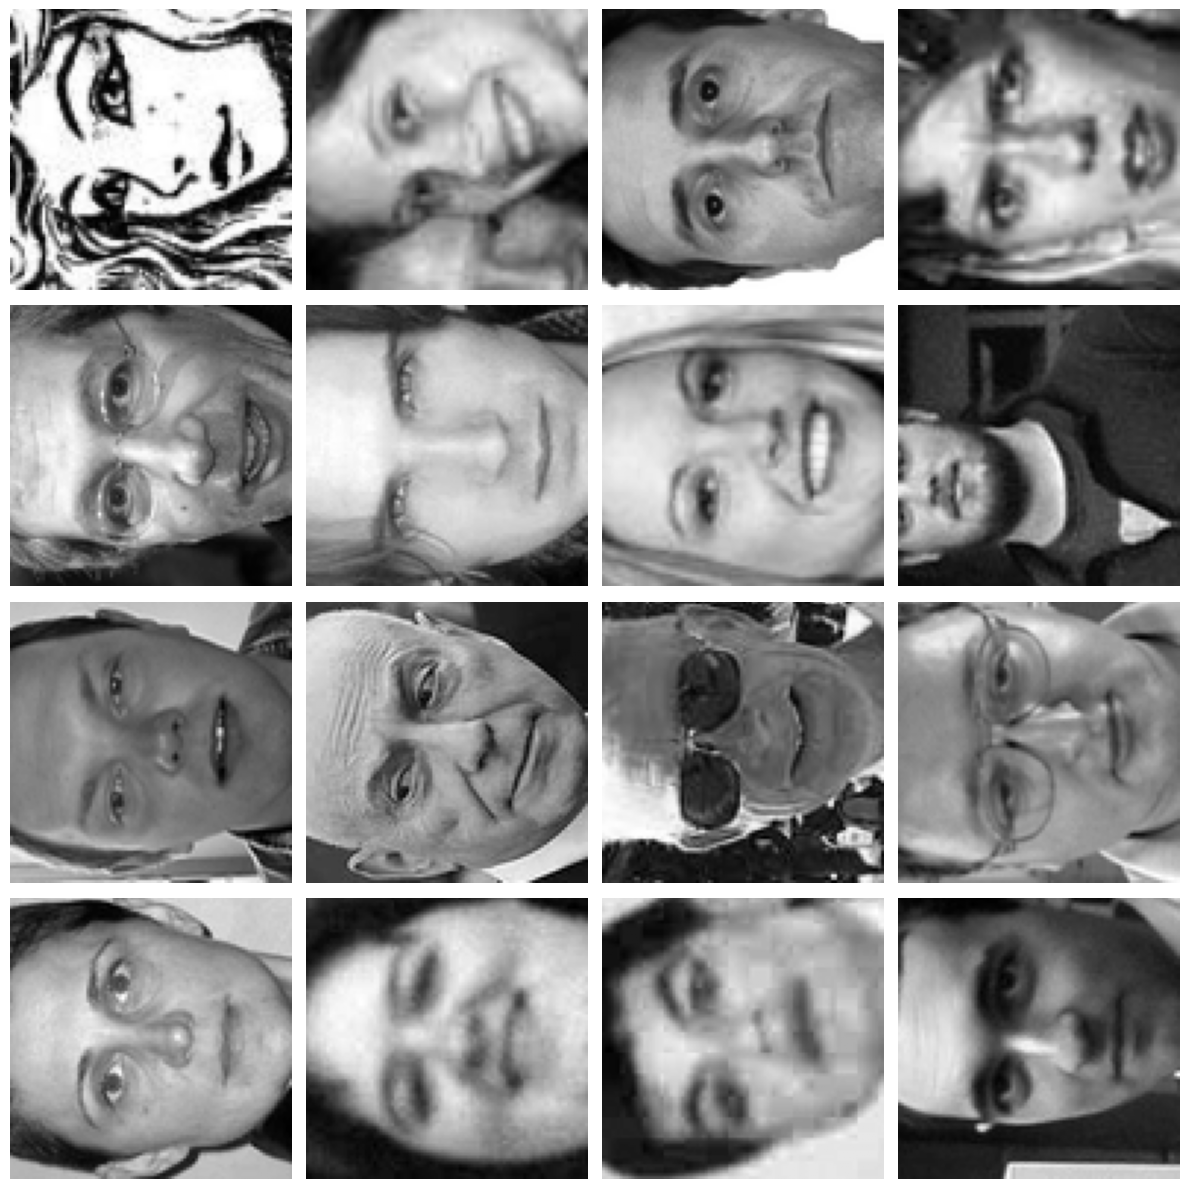

In [54]:
x = loadmat('faces.mat')['Data']
x = x.astype(np.float64)
max_row_by_row = x.max(axis=1, keepdims=True)
x = x / max_row_by_row
samples = 16
size=96
fig, ax = plt.subplots(int(samples/4), int(samples/4), figsize=(12, 12))

for idx, face in enumerate(np.random.choice(1000, samples)):
    row = idx // 4
    column = idx % 4
    face_image = x[face]
    face_image_reshaped = face_image.reshape(size, size).T
    ax[row, column].imshow(face_image_reshaped, cmap="gray")
    ax[row, column].axis('off')

plt.tight_layout()
plt.show()


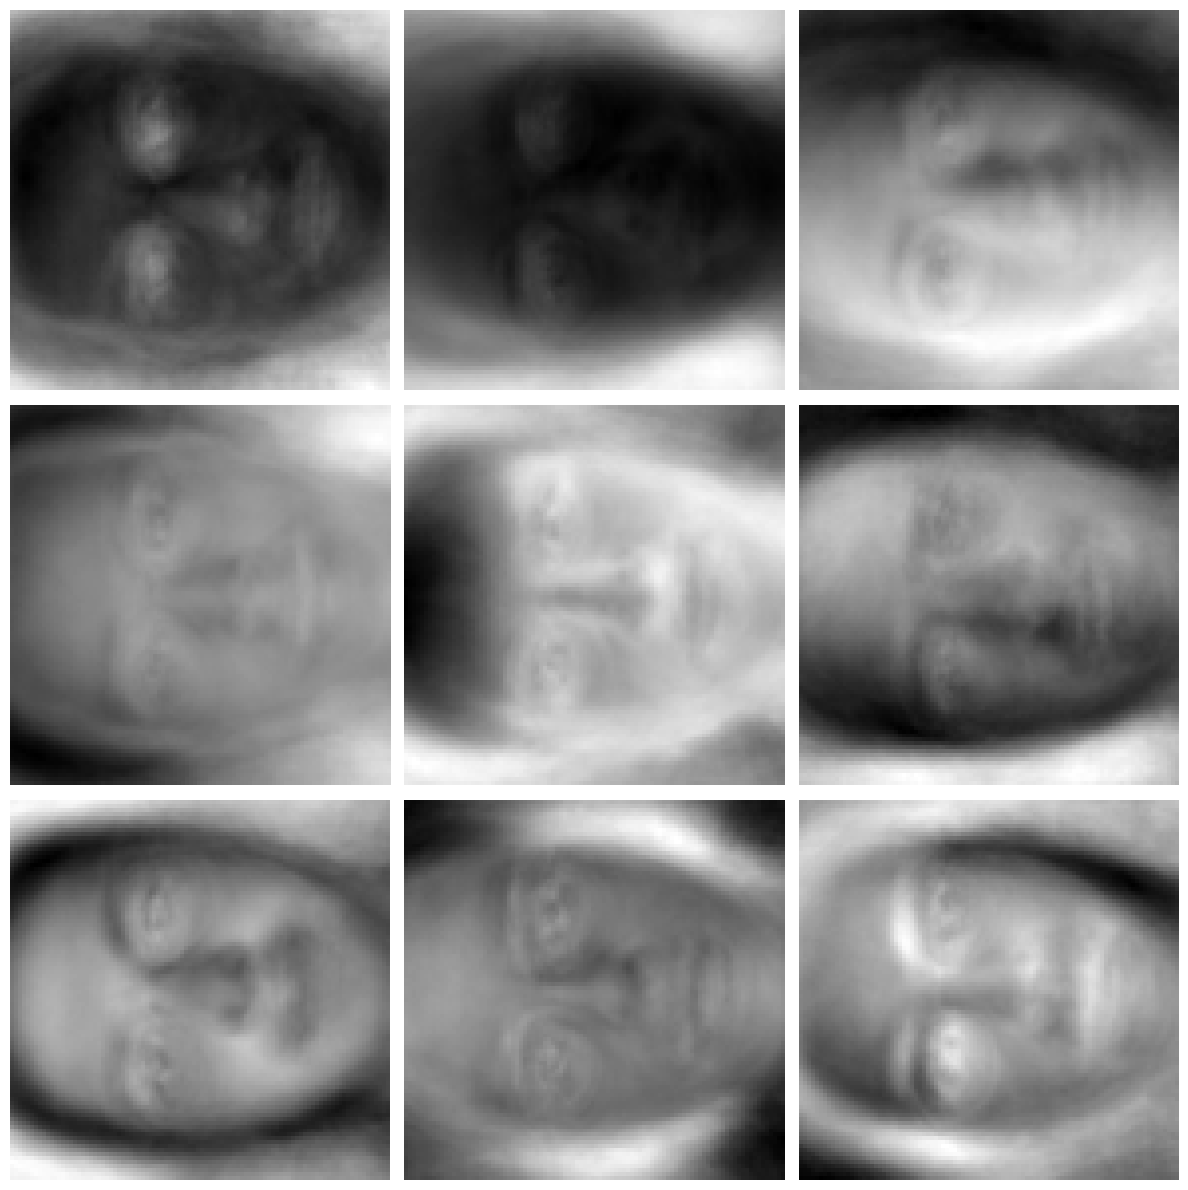

In [34]:
num_pc=9
components, variances = pca(x, m=num_pc)

fig, ax = plt.subplots(3, 3, figsize=(12, 12))

for i in range(num_pc):
    row = i // 3
    col = i % 3
    eigenface = components[:, i].reshape(96, 96).T
    
    im = ax[row, col].imshow(eigenface, cmap='gray')
    ax[row, col].axis('off')

plt.tight_layout()
plt.show()

# 5b

We observe that the variances for all 9 PCA variances match the values of v perfectly. Additionally, the dot products between the corresponding PCA components and SVD cols of V are all either -1 or 1, and thus, they are either identical or negated versions of one another. Thus we have shown programatically that they are equivalent! 

Proof of equivalence:

Beginning w/ with the covariance matrix:

$$
C = \frac{1}{n - 1} X^\top X
$$

Substitute in $X = USV^\top$:

$$
C = \frac{1}{n - 1} (USV^\top)^\top (USV^\top)
$$

$$
= \frac{1}{n - 1} V S^\top U^\top U S V^\top
$$

$$
= \frac{1}{n - 1} V S^\top S V^\top
$$

Since $S$ is diagonal by definition of the singular value decomp ($X = USV^\top$)

$$
C = \frac{1}{n - 1} V S^2 V^\top
= V \left( \frac{S^2}{n - 1} \right) V^\top
$$

This is the eigendecomposition of $C$. Therefore, I have shown that the eigenvectors of C (PCA components) = the columns of V (from SVD) and the eigenvalues of C (PCA variances) = s^2 / (n-1) as defined in the problem. I wont  go into the sign difference because the problem statement specifically mentions only having to explain why they are the same up until a sign change.


In [ ]:
x = loadmat('faces.mat')['Data']
x = x.astype(np.float64)
row_maxes = x.max(axis=1, keepdims=True)
x = x / row_maxes
num_components=9
n, p = x.shape
X_mean = x.mean(axis=0)
X_centered = x - X_mean
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
V = Vt.T 

v = (s**2) / (n - 1)
components_pca, variances_pca = pca(x, m=num_components)

In [36]:
print("\n")
print(f"FIRST 9 pca variances:")
for i in range(num_components):
    print(f"variance[{i}] = {variances_pca[i]:.2f}")

print("\n")
print(f"Comparison of variances:")
for i in range(num_components):
    diff = abs(variances_pca[i] - v[i])
    if diff < 1e-9:
        print(f"component={i} pca_value={variances_pca[i]:.4f} v_value={v[i]:.4f} difference={diff:4f} same=TRUE")
    else:
        print(f"component={i} pca_value={variances_pca[i]:.4f} v_value={v[i]:.4f} difference={diff:4f} same=FALSE")

V_9_components = V[:, :num_components]

print(f"\nShape comparison -> PCA components: {components_pca.shape} SVD V: {V_9_components.shape}")

print(f"\n")
print(f"{"[pc idx]"} {"[dot product]"} {"[same? (dot prod -1 or 1)]"}")
for i in range(num_components):
    dot_product = np.dot(components_pca[:, i], V_9_components[:, i])
    if abs(abs(dot_product)-1.0) < 1e-8:
        print(f"{i} {dot_product:.2f} {"TRUE"}")
    else:
        print(f"{i} {dot_product:.2f} {"FALSE"}")




FIRST 9 pca variances:
variance[0] = 120.14
variance[1] = 70.18
variance[2] = 46.51
variance[3] = 24.51
variance[4] = 19.13
variance[5] = 14.55
variance[6] = 9.79
variance[7] = 8.08
variance[8] = 7.36


Comparison of variances:
component=0 pca_value=120.1381 v_value=120.1381 difference=0.000000 same=TRUE
component=1 pca_value=70.1764 v_value=70.1764 difference=0.000000 same=TRUE
component=2 pca_value=46.5093 v_value=46.5093 difference=0.000000 same=TRUE
component=3 pca_value=24.5074 v_value=24.5074 difference=0.000000 same=TRUE
component=4 pca_value=19.1327 v_value=19.1327 difference=0.000000 same=TRUE
component=5 pca_value=14.5533 v_value=14.5533 difference=0.000000 same=TRUE
component=6 pca_value=9.7891 v_value=9.7891 difference=0.000000 same=TRUE
component=7 pca_value=8.0802 v_value=8.0802 difference=0.000000 same=TRUE
component=8 pca_value=7.3569 v_value=7.3569 difference=0.000000 same=TRUE

Shape comparison -> PCA components: (9216, 9) SVD V: (9216, 9)


[pc idx] [dot product] [